# What Are Embeddings?

Think of embeddings as a way to translate words into a language that computers understand - numbers!

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
# Simplified 2D example (real embeddings have hundereds of dimensions)
word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

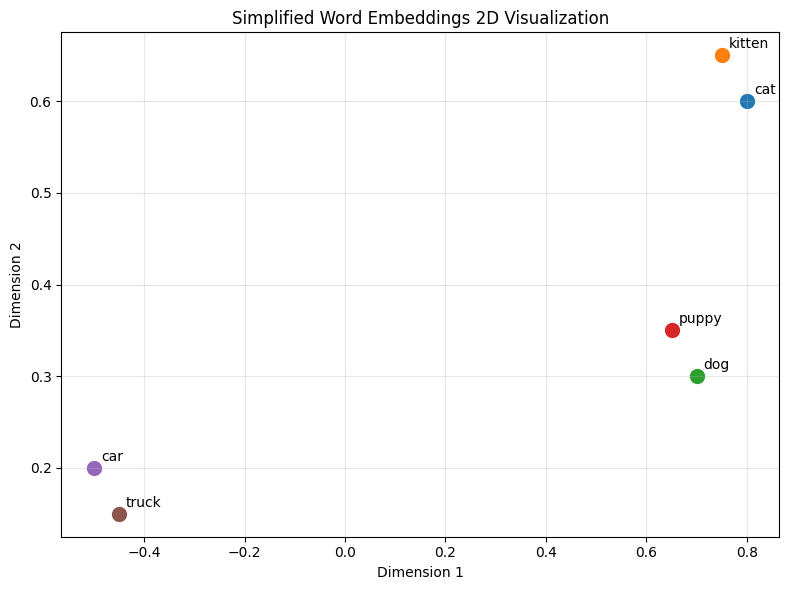

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

for word, embedding in word_embeddings.items():
    ax.scatter(embedding[0], embedding[1], s=100)  # Plot the point
    ax.annotate(word, (embedding[0], embedding[1]), xytext=(5, 5), textcoords='offset points')
    
ax.set_title('Simplified Word Embeddings 2D Visualization')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.grid(True, alpha=0.3)

plt. tight_layout()
plt.show()

## Measuring similarity

In [6]:
## Measuring similarity
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.
    - Result close to 1: very similar
    - Result close to 0: orthogonal (unrelated)
    - Result close to -1: opposite
    """
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0  # Avoid division by zero
    
    return dot_product / (norm_vec1 * norm_vec2)

In [7]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector, kitten_vector)
cat_car_similarity = cosine_similarity(cat_vector, car_vector)

print(f"Cosine similarity between cat and kitten: {cat_kitten_similarity:.2f}")
print(f"Cosine similarity between cat and car: {cat_car_similarity:.2f}")

Cosine similarity between cat and kitten: 1.00
Cosine similarity between cat and car: -0.44


## Creating Our First Embeddings

In [8]:
### Huggingface And OpenAI Models

from langchain_huggingface import HuggingFaceEmbeddings

## Initialize the HuggingFace embedding model(no API key needed!)
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
embedding_model

/Users/ravishankarkushwaha/Documents/Git Projects/RAGAcademy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16755.74it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [9]:
## Create our first embeddings
text = "Hello, I am learning about Embeddingd!"

embedding = embedding_model.embed_query(text)
print(f"Text: {text}")
print(f"Embedding length: {len(embedding)}")  # Print the length of the embedding vector
print(f"The embedding: {embedding}")  # Print the embedding vector

Text: Hello, I am learning about Embeddingd!
Embedding length: 384
The embedding: [-0.034420594573020935, -0.0839923843741417, 0.003665437689051032, -0.009570090100169182, 0.030806347727775574, 0.07357119023799896, -0.00023511874314863235, -0.012496261857450008, 0.018201187252998352, -0.0232704970985651, 0.016840167343616486, 0.07882049679756165, 0.042138487100601196, 0.027326015755534172, -0.0734836757183075, 0.018890276551246643, 0.0314515195786953, 0.10238993912935257, -0.0761532336473465, -0.005013505462557077, -0.02433459460735321, -0.039531826972961426, 0.04269447922706604, -0.08492455631494522, 0.023089144378900528, -0.012432082556188107, -0.019934650510549545, 0.04268375039100647, 0.09883162379264832, -0.08361496776342392, 0.07335574924945831, -0.01324619259685278, -0.027767060324549675, 0.07628867775201797, -0.048955582082271576, 0.09765886515378952, 0.05481857806444168, -0.013964108191430569, -0.08013243973255157, -0.005566880572587252, 0.01835346780717373, 0.0367682538926601

In [ ]:
sentences = [
    "the cat sat on the mat",
    "A feline rested on the rug",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]

embedding_sentences = embedding_model.embed_documents(sentences)
print(f"Sentences: {sentences}")
print(f"Embedding length: {len(embedding_sentences)}")  # Print the length of the embedding vector
print(f"The embedding: {embedding_sentences}")  # Print the embedding vector

Sentences: ['the cat sat on the mat', 'A feline rested on the rug', 'The dog played in the yard', 'I love programming in Python', 'Python is my favorite programming language']
Embedding length: 5
The embedding: [[0.1304018348455429, -0.011870157904922962, -0.028116976842284203, 0.05123862624168396, -0.05597446486353874, 0.030191557481884956, 0.030161350965499878, 0.024698320776224136, -0.01837056875228882, 0.05876680091023445, -0.024953152984380722, 0.06015422195196152, 0.039831675589084625, 0.0332304984331131, -0.06131143495440483, -0.04937312379479408, -0.05486350134015083, -0.04007607698440552, 0.05642915889620781, 0.039156604558229446, -0.034737106412649155, -0.013247744180262089, 0.03196623548865318, -0.06349913775920868, -0.06017855554819107, 0.07823453098535538, -0.028303926810622215, -0.04744283854961395, 0.040359288454055786, -0.006630966439843178, -0.0667409673333168, -0.004191308747977018, -0.02531166560947895, 0.05334169417619705, 0.01742803305387497, -0.09792362153530121, 

In [11]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "A lightweight model suitable for general-purpose embeddings, good quality.",
        "use_case": "General purpose, real-time applications"
    },
    "all-MPNet-base-v2": {
        "size": 768,
        "description": "A robust model for various NLP tasks. Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed, complex tasks"
    },
    "all-MiniLM-L12-v2": {
        "size": 768,
        "description": "Slightly better than L6, bit slower.",
        "use_case": "Good balance of speed and quality."
    },
    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering.",
        "use_case": "Question answering, semantic search"
    },
    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages, good for cross-lingual tasks.",
        "use_case": "Multilingual applications, cross-lingual search"
    }
}

print("Popular Open-Source HuggingFace Embedding Models Comparison\n")
for model_name, info in models.items():
    print(f"Model: {model_name}")
    print(f" - Size: {info['size']} dimensions")
    print(f" - Description: {info['description']}")
    print(f" - Best Use Case: {info['use_case']}\n")

Popular Open-Source HuggingFace Embedding Models Comparison

Model: all-MiniLM-L6-v2
 - Size: 384 dimensions
 - Description: A lightweight model suitable for general-purpose embeddings, good quality.
 - Best Use Case: General purpose, real-time applications

Model: all-MPNet-base-v2
 - Size: 768 dimensions
 - Description: A robust model for various NLP tasks. Best quality, slower than MiniLM
 - Best Use Case: When quality matters more than speed, complex tasks

Model: all-MiniLM-L12-v2
 - Size: 768 dimensions
 - Description: Slightly better than L6, bit slower.
 - Best Use Case: Good balance of speed and quality.

Model: multi-qa-MiniLM-L6-cos-v1
 - Size: 384 dimensions
 - Description: Optimized for question-answering.
 - Best Use Case: Question answering, semantic search

Model: paraphrase-multilingual-MiniLM-L12-v2
 - Size: 384 dimensions
 - Description: Supports 50+ languages, good for cross-lingual tasks.
 - Best Use Case: Multilingual applications, cross-lingual search

